In [39]:
import numpy as np
import torch
from data_aware_dp import sampling 
from matplotlib import pyplot as plt


In [26]:
beta = 1
c = 1

sampler = sampling.beta_exponential_sampler(beta=beta, c=c) # this is X


(1000000, 1)

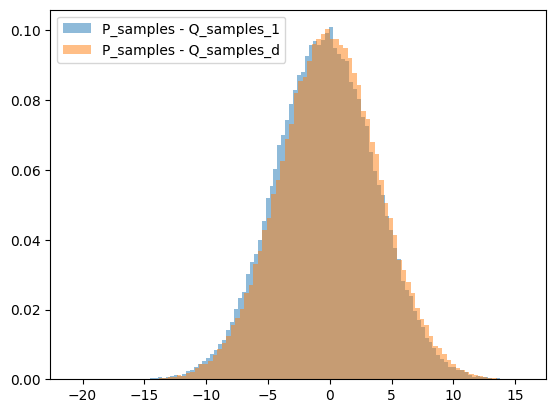

In [46]:
def P(beta, d , N ):
    samples = sampler(N* d)
    samples = samples.reshape(N, d)
    sample_norms = np.linalg.norm(samples, axis=1, ord=beta)
    return sample_norms

def Q(beta, d, N, mu):
    samples = sampler(N* d)
    samples = samples.reshape(N, d)
    # subtract each sample from mu
    samples = samples - mu
    sample_norms = np.linalg.norm(samples, axis=1, ord=beta)
    return sample_norms

def mu_1(d):
    mu = np.zeros(d) # one hot
    mu[0] = 1
    return mu

def mu_d(d):
    mu = np.ones(d)
    mu = mu / np.linalg.norm(mu, ord=beta)
    return mu 

N = int(1e5)
beta = 1.1
d = 100

P_samples = P(beta, d, N)
Q_samples_1 = Q(beta, d, N, mu_1(d))
Q_samples_d = Q(beta, d, N, mu_d(d))

# plot histogram of P_samples - Q_samples_1
plt.hist(P_samples - Q_samples_1, bins=100, density=True, label='P_samples - Q_samples_1', alpha=0.5)
plt.hist(P_samples - Q_samples_d, bins=100, density=True, label='P_samples - Q_samples_d', alpha=0.5)
plt.legend()
plt.show()



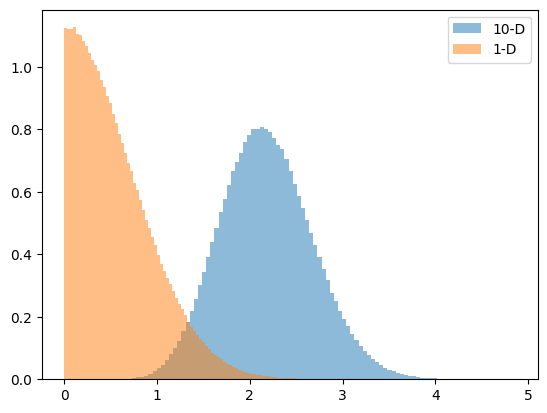

In [ ]:
N = int(1e6)
d = 10
# d dimensional generalized gaussian


beta,c = 2,1

sampler = sampling.beta_exponential_sampler(beta=beta, c=c) # this is X


samples_d = sampler(N*d)
samples_d = samples_d.reshape(N, d)

samples_1 = sampler(N)
samples_1 = samples_1.reshape(N, 1)


# take l-beta norm
sample_d_norms = np.linalg.norm(samples_d, axis=1, ord=beta)
sample_d_norms.shape
#sample_1_norms = np.linalg.norm(samples_1, axis=1, ord=beta) # just the absolute value
sample_1_norms = np.linalg.norm(samples_1, axis=1, ord=beta)

plt.hist(sample_d_norms, bins=100, density=True, label=f'{d}-D', alpha=0.5) 
plt.hist(sample_1_norms, bins=100, density=True, label='1-D', alpha=0.5)
plt.legend()
plt.show()

